# An investigation of classification methods for Diabetes 130-US Hospitals

### Data Exploration 

In [4]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 
  
# data (as pandas dataframes) 
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features 
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets 
  
# metadata 
# print(diabetes_130_us_hospitals_for_years_1999_2008.metadata) 
  
#got this info above from the dataset page (^)

# variable information 
# print(diabetes_130_us_hospitals_for_years_1999_2008.variables) 

print(f"Rows: {X.shape[0]}, Columns: {X.shape[1]}")

print("\nMissing values per column:")
missing = (X == '?').sum()
missing = missing[missing > 0]
print(missing)

print("\nClass distribution:")
print(y['readmitted'].value_counts())

/opt/miniconda3/envs/cs178/lib/python3.10/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Rows: 101766, Columns: 47

Missing values per column:
Series([], dtype: int64)

Class distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


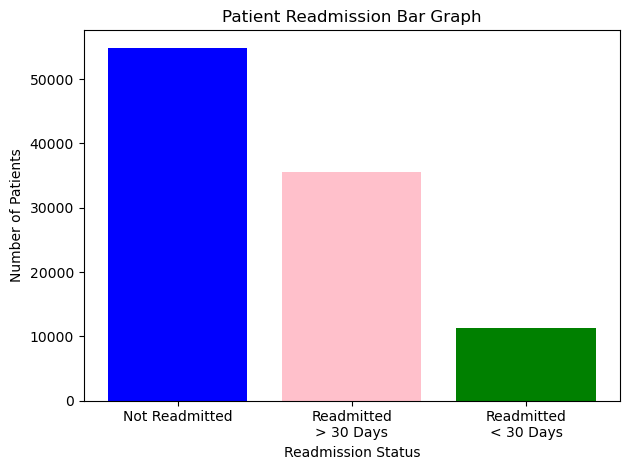

In [ ]:
import matplotlib.pyplot as plt

#labels = ['Not Readmitted', 'Readmitted after more than 30 Days', 'Readmitted after less than 30 Days']
labels = ['Not Readmitted', 'Readmitted\n> 30 Days', 'Readmitted\n< 30 Days']
counts = [
    (y['readmitted'] == 'NO').sum(),
    (y['readmitted'] == '>30').sum(),
    (y['readmitted'] == '<30').sum()
]

plt.bar(labels, counts, color=['blue', 'pink', 'green'])
plt.title('Patient Readmission Bar Graph')
plt.xlabel('Readmission Status')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

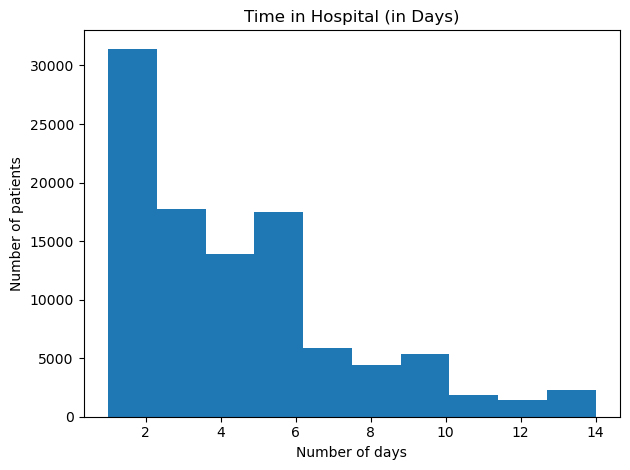

In [18]:
plt.hist(X['time_in_hospital'])
plt.title('Time in Hospital (in Days)')
plt.xlabel('Number of days')
plt.ylabel('Number of patients')
plt.tight_layout()
plt.show()

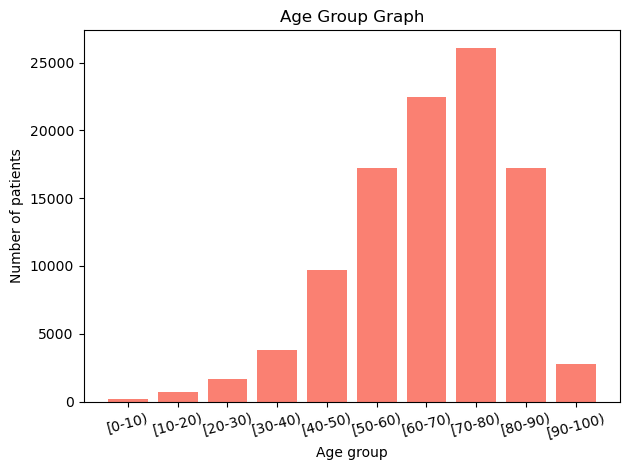

In [28]:
age_counts = X['age'].value_counts().sort_index()

plt.bar(age_counts.index, age_counts.values, color='salmon')
plt.title('Age Group Graph')
plt.xlabel('Age group')
plt.ylabel('Number of patients')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

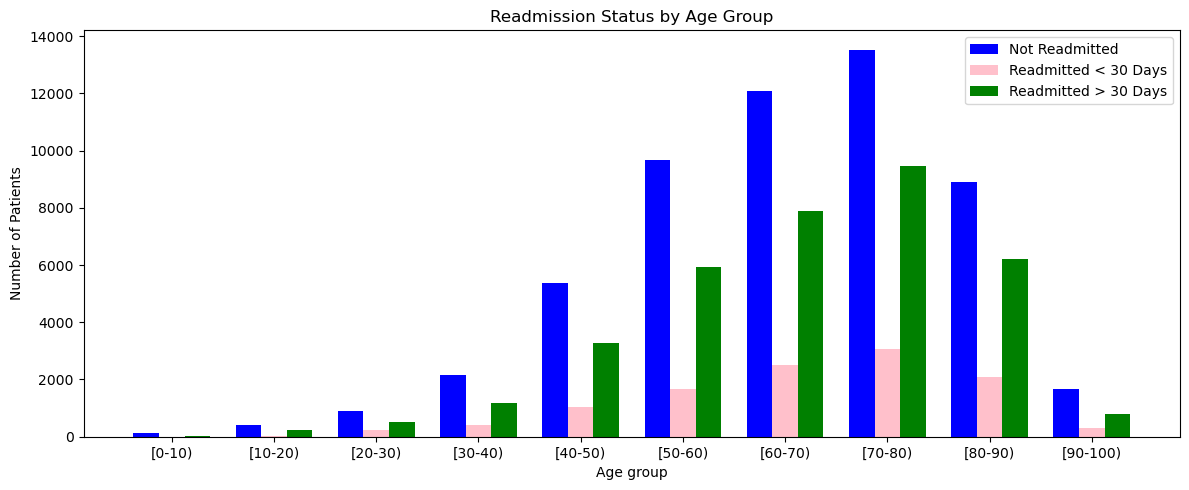

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x_copy = X.copy()
x_copy['readmitted'] = y['readmitted'].values

no_readmit = x_copy[x_copy['readmitted'] == 'NO']
less_than_30_readmit = x_copy[x_copy['readmitted'] == '<30']
greater_than_30_readmit = x_copy[x_copy['readmitted'] == '>30']

age_order = sorted(x_copy['age'].unique())

no_patients = []
less_than_30_patients = []
greater_than_30_patients = []

for i in age_order:
    no_patients.append(len(no_readmit[no_readmit['age'] == i]))
    less_than_30_patients.append(len(less_than_30_readmit[less_than_30_readmit['age'] == i]))
    greater_than_30_patients.append(len(greater_than_30_readmit[greater_than_30_readmit['age'] == i]))

w, x = 0.25, np.arange(len(age_order))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, no_patients, width=w, label='Not Readmitted', color='blue')
ax.bar(x, less_than_30_patients, width=w, label='Readmitted < 30 Days', color='pink')
ax.bar(x + w, greater_than_30_patients, width=w, label='Readmitted > 30 Days', color='green')
ax.set_xticks(x)
ax.set_xticklabels(age_order)
ax.set_ylabel('Number of patients')
ax.set_xlabel('Age group')
ax.set_title('Readmission Status by Age Group')
ax.legend()
plt.tight_layout()
plt.show()


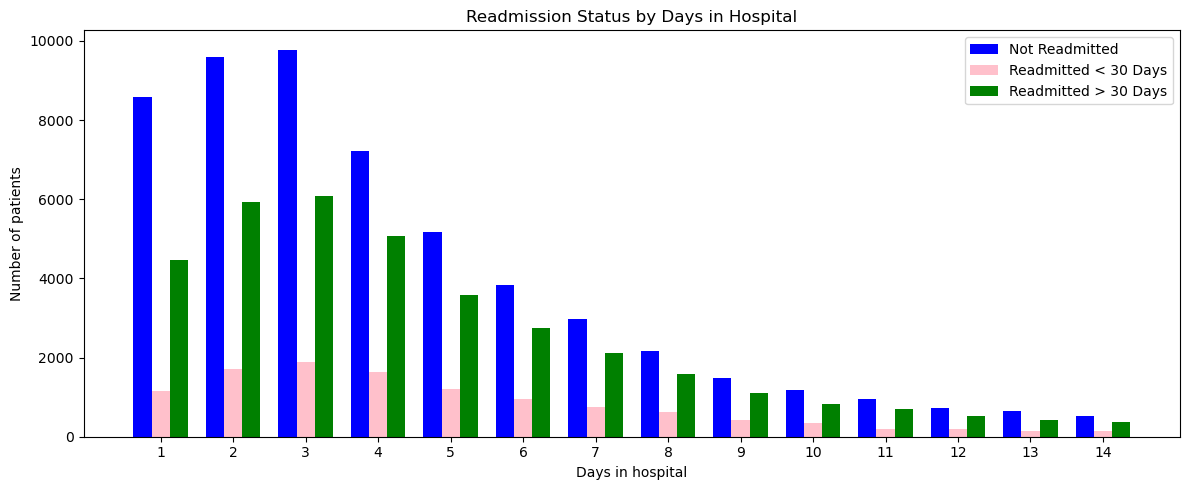

In [69]:
days = list(range(1, 15))

no_days = []
less_than_30_days = []
greater_than_30_days = []

for i in days:
    no_days.append(len(no_readmit[no_readmit['time_in_hospital'] == i]))
    less_than_30_days.append(len(less_than_30_readmit[less_than_30_readmit['time_in_hospital'] == i]))
    greater_than_30_days.append(len(greater_than_30_readmit[greater_than_30_readmit['time_in_hospital'] == i]))

w, x = 0.25, np.arange(len(days))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, no_days, width=w, label='Not Readmitted', color='blue')
ax.bar(x,less_than_30_days, width=w, label='Readmitted < 30 Days', color='pink')
ax.bar(x + w, greater_than_30_days, width=w, label='Readmitted > 30 Days', color='green')
ax.set_xticks(x)
ax.set_xticklabels(days)
ax.set_xlabel('Days in hospital')
ax.set_ylabel('Number of patients')
ax.set_title('Readmission Status by Days in Hospital')
ax.legend()
plt.tight_layout()
plt.show()

### Feedforward Neural Networks

### KNN

In [79]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

X_clean = X.copy()
for col in X_clean.columns:
    if X_clean[col].dtype == 'object':
        X_clean[col] = X_clean[col].fillna(X_clean[col].mode()[0])
    else:
        X_clean[col] = X_clean[col].fillna(X_clean[col].mean())

for col in X_clean.select_dtypes(include='object').columns:
    X_clean[col] = LabelEncoder().fit_transform(X_clean[col].astype(str))

y_enc = LabelEncoder().fit_transform(y.values.ravel())

seed = 1234
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_enc, test_size=0.20, random_state=seed)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=seed)

print(f"Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Train: 61059, Validation: 20353, Test: 20354


In [81]:
k_values = [1, 10, 50, 100, 500, 1000]
val_errors = []
train_errors = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, knn.predict(X_train))
    val_acc = accuracy_score(y_val, knn.predict(X_val))
    
    train_errors.append(1 - train_acc)
    val_errors.append(1 - val_acc)
    
    print(f"k={k}, train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

k=1, train_acc=1.0000, val_acc=0.4683
k=10, train_acc=0.6220, val_acc=0.5318
k=50, train_acc=0.5798, val_acc=0.5616
k=100, train_acc=0.5738, val_acc=0.5650
k=500, train_acc=0.5608, val_acc=0.5633
k=1000, train_acc=0.5573, val_acc=0.5615


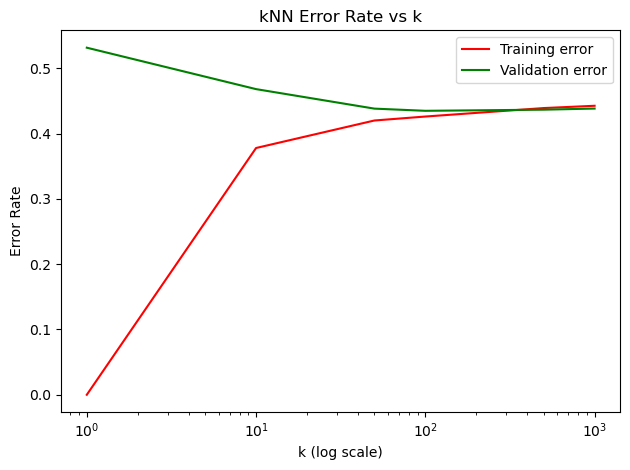

In [82]:
import matplotlib.pyplot as plt

plt.semilogx(k_values, train_errors, color='red', label='Training error')
plt.semilogx(k_values, val_errors, color='green', label='Validation error')
plt.xlabel('k (log scale)')
plt.ylabel('Error Rate')
plt.title('kNN Error Rate vs k')
plt.legend()
plt.tight_layout()
plt.show()

In [83]:
best_k = k_values[np.argmin(val_errors)]
print(f"Best k = {best_k}")

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)

print("\nTest Accuracy:", accuracy_score(y_test, knn_final.predict(X_test)))
print(classification_report(y_test, knn_final.predict(X_test),
      target_names=['<30 days', 'Not Readmitted', '>30 days']))

Best k = 100

Test Accuracy: 0.5629360322295371
                precision    recall  f1-score   support

      <30 days       0.64      0.01      0.01      2308
Not Readmitted       0.49      0.22      0.30      7106
      >30 days       0.58      0.90      0.70     10940

      accuracy                           0.56     20354
     macro avg       0.57      0.38      0.34     20354
  weighted avg       0.55      0.56      0.48     20354

